### XLNet 
- decoder only architecture
- improved contextual understanding
- can capture biderectional context effectively
- predicting each word by by considering all other words
- understand relationships between words, catch long-range deps

### Finetuning xlnet with labeled dataset


In [3]:
import pandas as pd
import numpy as np
from cleantext import clean
import re
from transformers import XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer, pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets
import random
import evaluate

Since the GPL-licensed package `unidecode` is not installed, using Python's `unicodedata` package which yields worse results.


In [5]:
dataTrain = pd.read_csv("./emotions_data/emotion-labels-train.csv")
dataTest = pd.read_csv("./emotions_data/emotion-labels-test.csv")
dataVal = pd.read_csv("./emotions_data/emotion-labels-val.csv")

In [6]:
dataTrain.head(10)

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy
5,"Today I reached 1000 subscribers on YT!! , #go...",joy
6,"@Singaholic121 Good morning, love! Happy first...",joy
7,#BridgetJonesBaby is the best thing I've seen ...,joy
8,Just got back from seeing @GaryDelaney in Burs...,joy
9,@IndyMN I thought the holidays could not get a...,joy


In [74]:
data = pd.concat([dataTrain, dataTest, dataVal], ignore_index = True)

In [75]:
data["textClean"] = data["text"].apply(lambda x: clean(x, no_emoji=True))

In [76]:
data["textClean"] = data["textClean"].apply(lambda x:re.sub("@[^\s]+", "", x))
data.head()

,text,label,textClean
0,Just got back from seeing @GaryDelaney in Burs...,joy,just got back from seeing in burslem. amazing...
1,Oh dear an evening of absolute hilarity I don'...,joy,oh dear an evening of absolute hilarity i don'...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,been waiting all week for this game #cheer #fr...
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,": thank you so much, gloria! you're so sweet,..."
4,I feel so blessed to work with the family that...,joy,i feel so blessed to work with the family that...


<Axes: xlabel='label'>

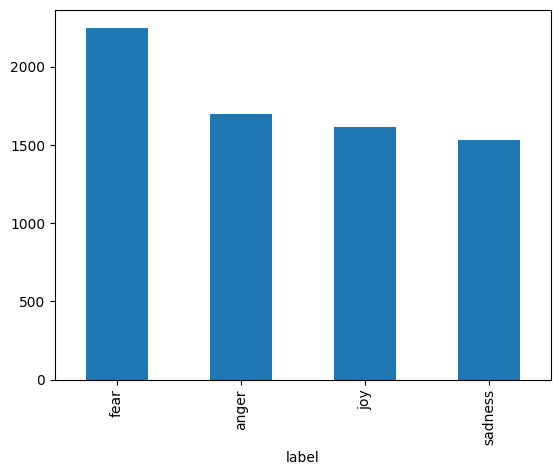

In [77]:
data["label"].value_counts().plot(kind="bar")

In [78]:
# pandas.DataFrame.sample(n) => returns a random sample of items from an axis of object
g = data.groupby('label')
data = pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))

<Axes: xlabel='label'>

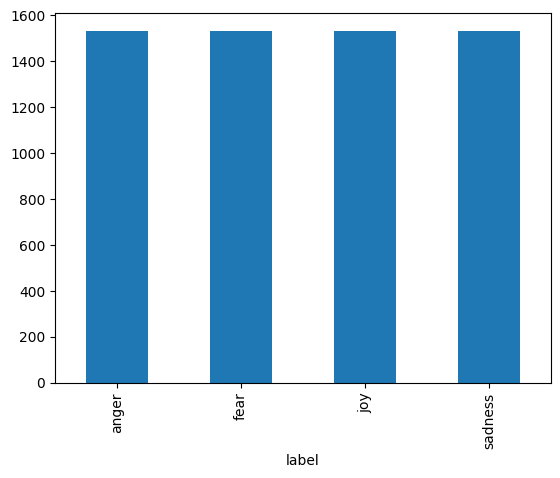

In [79]:
data["label"].value_counts().plot(kind="bar")

In [21]:
data["labelInt"] = LabelEncoder().fit_transform(data["label"])

In [22]:
NUM_LABELS = 4
trainSplit, testSplit = train_test_split(data, train_size = 0.8)
trainSplit, valSplit = train_test_split(trainSplit, train_size = 0.9)

In [28]:
print(len(trainSplit))
print(len(testSplit))
print(len(valSplit)) # validation

4414
1227
491


In [33]:
trainSplit.head(5)

text    label   
label                                                                      
anger   725      Lol little things like that make me so angry x    anger  \
fear    58    I polished my nails, but can't find the polish...     fear   
        995   Did you know I specialise in #anxiety  and #pa...     fear   
        1346  World wants #peace from  #WorldPeaceDay #inter...     fear   
sadness 396   @BeenishParvez salaams ma'am, how r u ma'am? M...  sadness   

                                                      textClean  labelInt  
label                                                                      
anger   725      lol little things like that make me so angry x         0  
fear    58    i polished my nails, but can't find the polish...         1  
        995   did you know i specialise in #anxiety and #pan...         1  
        1346  world wants #peace from #worldpeaceday #intern...         1  
sadness 396    salaams ma'am, how r u ma'am? may allah prote...         3

In [36]:
print(trainSplit.labelInt.values)

[0 1 1 ... 2 3 2]


In [45]:
trainDf = pd.DataFrame({
    "label": trainSplit.labelInt.values,
    "text": trainSplit.textClean.values,
})

testDf = pd.DataFrame({
    "label": testSplit.labelInt.values,
    "text": testSplit.textClean.values,
})

In [46]:
trainDf = datasets.Dataset.from_dict(trainDf)
testDf = datasets.Dataset.from_dict(testDf)

In [50]:
print(trainDf[0])
print(trainDf["text"][:5])

{'label': 0, 'text': 'lol little things like that make me so angry x'}
['lol little things like that make me so angry x', "i polished my nails, but can't find the polish remover. it look like a 3yr old polished my nails lol", 'did you know i specialise in #anxiety and #panic attacks? get in touch for all of my solutions for you. #coventry', 'world wants #peace from #worldpeaceday #internationaldayofpeace', " salaams ma'am, how r u ma'am? may allah protect u from sadness, illness, harm & nazr-e-bad. aameen. stay blessed ma'am."]


In [52]:
datasetDic = datasets.DatasetDict({"train":trainDf, "test":testDf})
datasetDic

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

### Embeddings

In [53]:
# model and tokenizer are downloaded from the HuggingFace Hub
# ~/.cache/huggingface
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

D:\anaconda3\envs\llm\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Josip\.cache\huggingface\hub\models--xlnet-base-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

In [54]:
def tokenize(examples):
    return tokenizer(examples["text"], padding="max_length", max_length=128, truncation=True)

In [56]:
tokenizedDatasets = datasetDic.map(tokenize, batched=True)

Map:   0%|          | 0/4414 [00:00<?, ? examples/s]

Map:   0%|          | 0/1227 [00:00<?, ? examples/s]

In [58]:
tokenizedDatasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [59]:
tokenizedDatasets["train"]["text"][0]

'lol little things like that make me so angry x'

In [61]:
print(tokenizedDatasets["train"]["input_ids"][0], end = " ")

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 17, 18535, 293, 406, 115, 29, 144, 110, 102, 4472, 3512, 4, 3] 

In [63]:
print(tokenizer.decode(5), tokenizer.decode(4), tokenizer.decode(17), tokenizer.decode(3))

<pad> <sep>  <cls>


In [65]:
print(tokenizedDatasets["train"]["token_type_ids"][0], end = " ")

[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2] 

In [66]:
print(tokenizedDatasets["train"]["attention_mask"][0], end = " ")

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 

In [67]:
smallTrainDatasets = tokenizedDatasets["train"].shuffle(seed=42).select(range(100))
smallTestnDatasets = tokenizedDatasets["test"].shuffle(seed=42).select(range(100))

### Finetuning

In [81]:
model = XLNetForSequenceClassification.from_pretrained("xlnet-base-cased",
                                                       num_labels= NUM_LABELS,
                                                       id2label={0: "anger", 1:"fear", 2:"joy", 3: "sadness"}) # mapping

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [83]:
metric = evaluate.load("accuracy") # which measurement to evaluate when its training

ConnectionError: HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out.

In [ ]:
def computeMetrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)